# Capítulo 3: Sistemas mecánicos y eléctricos

[![Abrir en Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/jfbonder/imc/blob/main/notebooks/02-mecanicos.ipynb)

Notebook que acompaña al Capítulo 3 de *Introducción al Modelado Continuo*: oscilador armónico, resorte con fricción, péndulo, circuitos RLC y el circuito de van der Pol (el segundo problema conductor). Cada figura de las notas sale de una celda marcada con su nombre de archivo. Los esquemas `Resorte.png` y `Pendulo.png` son dibujos y no se generan acá.

Las herramientas son sólo las del capítulo: reducción a un sistema de primer orden $(x, v)$, la energía $E$ y el signo de $\dot E$ a lo largo de las soluciones, y simulación numérica. No se linealiza nada ni se clasifican equilibrios: lo que el texto afirma se verifica mirando las soluciones.

In [1]:
# Configuración (funciona en Colab y en una copia local del repositorio)
try:
    import imc
except ImportError:
    import subprocess, sys
    subprocess.run([sys.executable, "-m", "pip", "install", "-q", "git+https://github.com/jfbonder/imc.git"], check=True)
    import imc

import numpy as np
import matplotlib.pyplot as plt
from scipy.integrate import solve_ivp
from imc import estilo
from imc.estilo import COLORES, CICLO

GUARDAR = False   # True para regenerar las figuras de las notas en figuras/


def fuente(F=14, lw=1.6):
    """Tamaño de letra y grosor de línea. Las figuras de un panel (6 x 4 in, a 0.6 textwidth) usan F = 14;
    las de varios paneles (a 0.8-0.9 textwidth) usan F = 15 y lw = 2, y al final de la celda se vuelve a fuente()."""
    estilo.activar(fuente=F)
    plt.rcParams["lines.linewidth"] = lw

fuente()


def simular(F, X0, T, args=(), n=2000):
    """Integra X' = F(t, X) en [0, T] con tolerancias finas y devuelve (t, X) en n instantes."""
    sol = solve_ivp(F, (0, T), X0, args=args, rtol=1e-10, atol=1e-12, dense_output=True, max_step=T / n)
    t = np.linspace(0, T, n)
    return t, sol.sol(t)


def periodo(t, x, descartar=0.0):
    """Período medido como la distancia media entre cruces ascendentes de x por su valor medio,
    usando sólo t > descartar (para saltear el transitorio). Devuelve nan si no hay dos cruces."""
    m = t > descartar
    t, x = t[m], x[m] - x[m].mean()
    k = np.where((x[:-1] < 0) & (x[1:] >= 0))[0]
    if len(k) < 2:
        return np.nan
    tc = t[k] - x[k] * (t[k + 1] - t[k]) / (x[k + 1] - x[k])   # interpolación lineal del cruce
    return np.mean(np.diff(tc))

## 3.2 El oscilador armónico

$m\ddot x + kx = 0$, o como sistema de primer orden (Sección 3.7),
$$\dot x = v,\qquad \dot v = -\frac{k}{m}\,x .$$

La energía $E(x,v) = \tfrac12 m v^2 + \tfrac12 k x^2$ se conserva, así que en el plano $(x,v)$ las trayectorias son las elipses $E = $ cte y el movimiento es periódico. El período (que se lee de la simulación) es $2\pi\sqrt{m/k}$, independiente de la amplitud.

*Figura nueva `oscilador-armonico`: $x(t)$ y plano de fases del oscilador armónico.*

x0 = 0.5: período medido = 3.14159,  E max - E min = 1.1e-12
x0 = 1.0: período medido = 3.14159,  E max - E min = 4.4e-12


x0 = 1.5: período medido = 3.14159,  E max - E min = 9.8e-12
2 pi sqrt(m/k) = 3.14159


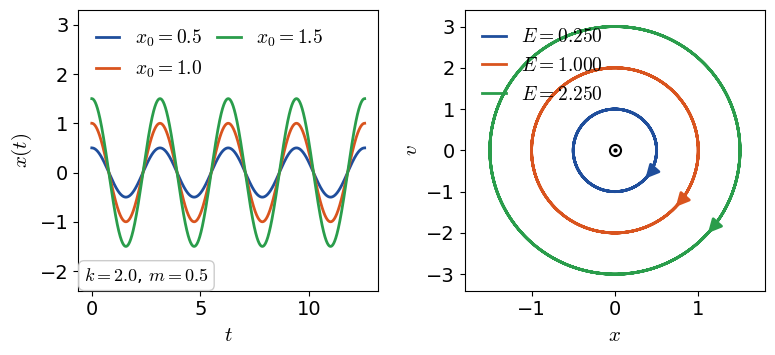

In [2]:
def oscilador(t, X, k, m=1.0):
    x, v = X
    return [v, -k / m * x]

k, m = 2.0, 0.5
E_osc = lambda x, v: 0.5 * m * v**2 + 0.5 * k * x**2
T = 4 * 2 * np.pi * np.sqrt(m / k)

fuente(15, lw=2)
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(8, 3.8))
for x0, c in zip([0.5, 1.0, 1.5], CICLO):
    t, (x, v) = simular(oscilador, [x0, 0.0], T, args=(k, m))
    ax1.plot(t, x, color=c, label=f"$x_0 = {x0}$")
    ax2.plot(x, v, color=c, label=f"$E = {E_osc(x0, 0):.3f}$")
    ax2.annotate("", xy=(x[60], v[60]), xytext=(x[55], v[55]), arrowprops=dict(arrowstyle="-|>", color=c, mutation_scale=20, lw=2))
    print(f"x0 = {x0}: período medido = {periodo(t, x):.5f},  E max - E min = {np.ptp(E_osc(x, v)):.1e}")
print(f"2 pi sqrt(m/k) = {2 * np.pi * np.sqrt(m / k):.5f}")
ax1.set_ylim(-2.4, 3.3); ax1.set_xlabel("$t$"); ax1.set_ylabel("$x(t)$"); ax1.legend(loc="upper left", ncol=2, handlelength=1.2, columnspacing=0.8)
ax2.set_xlabel("$x$"); ax2.set_ylabel("$v$"); ax2.set_xlim(-1.8, 1.8); ax2.set_ylim(-3.4, 3.4); ax2.legend(loc="upper left", handlelength=1.2)
ax2.plot(0, 0, "o", ms=8, color="white", mec="black", mew=1.5); ax2.plot(0, 0, ".", ms=4, color="black")
estilo.parametros(ax1, rf"$k = {k}$, $m = {m}$", loc="lower left", fontsize=13)
fig.tight_layout(); fuente()
if GUARDAR: estilo.guardar(fig, "oscilador-armonico")

## 3.3 El resorte con fricción

$m\ddot x + \gamma\dot x + kx = 0$, es decir $\dot x = v$, $\dot v = -\frac{k}{m}x - \frac{\gamma}{m}v$.

Según el tamaño de $\gamma$ frente a $2\sqrt{km}$ el resorte oscila mientras se frena (sub-amortiguado), o vuelve al reposo sin oscilar (crítico y sobre-amortiguado). En el plano $(x,v)$ la trayectoria cruza las elipses de nivel de $E$ hacia adentro, porque $\dot E = -\gamma v^2 \le 0$.

*Figura nueva `resorte-friccion`: $x(t)$ en los tres regímenes (misma condición inicial) y plano de fases del caso sub-amortiguado sobre las curvas de nivel de $E$.*

2 sqrt(km) = 2.00


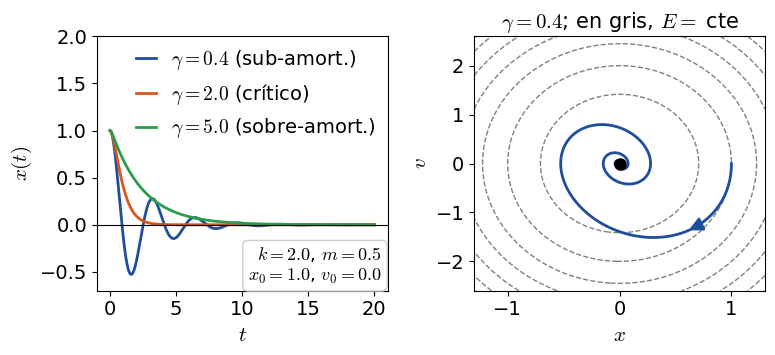

In [3]:
def resorte(t, X, k, gamma, m=1.0):
    x, v = X
    return [v, -k / m * x - gamma / m * v]

k, m = 2.0, 0.5
x0, v0 = 1.0, 0.0
regimenes = [(0.4, "sub-amort."), (2.0, "crítico"), (5.0, "sobre-amort.")]
print(f"2 sqrt(km) = {2 * np.sqrt(k * m):.2f}")

fuente(15, lw=2)
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(8, 3.8))
for (gamma, nombre), c in zip(regimenes, CICLO):
    t, (x, v) = simular(resorte, [x0, v0], 20, args=(k, gamma, m))
    ax1.plot(t, x, color=c, label=rf"$\gamma = {gamma}$ ({nombre})")
ax1.axhline(0, color="black", lw=0.8)
ax1.set_ylim(-0.7, 2.0); ax1.set_xlabel("$t$"); ax1.set_ylabel("$x(t)$"); ax1.legend(loc="upper right", handlelength=1.0, borderaxespad=0.2)
estilo.parametros(ax1, rf"$k = {k}$, $m = {m}$" + "\n" + rf"$x_0 = {x0}$, $v_0 = {v0}$", loc="lower right", fontsize=13)

# plano de fases del sub-amortiguado sobre las elipses E = cte
gamma = regimenes[0][0]
xx, vv = np.meshgrid(np.linspace(-1.3, 1.3, 200), np.linspace(-2.6, 2.6, 200))
ax2.contour(xx, vv, E_osc(xx, vv), levels=6, colors=[COLORES["gris"]], linewidths=1.0, linestyles="--")
t, (x, v) = simular(resorte, [x0, v0], 25, args=(k, gamma, m))
ax2.plot(x, v, color=COLORES["traj"])
ax2.annotate("", xy=(x[40], v[40]), xytext=(x[35], v[35]), arrowprops=dict(arrowstyle="-|>", color=COLORES["traj"], mutation_scale=20, lw=2))
ax2.plot(0, 0, "o", ms=8, color="black")
ax2.set_xlabel("$x$"); ax2.set_ylabel("$v$")
ax2.set_title(rf"$\gamma = {gamma}$; en gris, $E =$ cte")
fig.tight_layout(); fuente()
if GUARDAR: estilo.guardar(fig, "resorte-friccion")

### Verificación: $\dot E = -\gamma v^2 \le 0$

Calculamos $E(t)$ a lo largo de la solución sub-amortiguada, derivamos numéricamente y comparamos con $-\gamma v^2$. $E$ decrece siempre, y deja de decrecer justo en los instantes en que $v = 0$ (los extremos de $x$).

max |dE/dt + gamma v^2| = 3.3e-04   (error de la derivada numérica)
max dE/dt = -1.5e-12  ->  E nunca crece


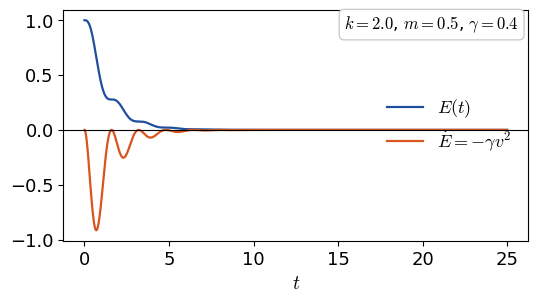

In [4]:
t, (x, v) = simular(resorte, [x0, v0], 25, args=(k, gamma, m))
E = E_osc(x, v)
dE = np.gradient(E, t)
print(f"max |dE/dt + gamma v^2| = {np.max(np.abs(dE + gamma * v**2)):.1e}   (error de la derivada numérica)")
print(f"max dE/dt = {dE.max():.1e}  ->  E nunca crece")

fig, ax = plt.subplots(figsize=(6, 3))
ax.plot(t, E, label="$E(t)$")
ax.plot(t, -gamma * v**2, label=r"$\dot E = -\gamma v^2$")
ax.axhline(0, color="black", lw=0.8)
ax.set_xlabel("$t$"); ax.legend(loc="center right")
estilo.parametros(ax, rf"$k = {k}$, $m = {m}$, $\gamma = {gamma}$", fontsize=12)

## 3.4 El péndulo simple

$$\ddot\theta + \frac{g}{\ell}\sin\theta = 0 \qquad\Longleftrightarrow\qquad \dot\theta = \omega,\quad \dot\omega = -\frac{g}{\ell}\sin\theta .$$

Para amplitudes chicas $\sin\theta \approx \theta$ y el péndulo se parece al oscilador armónico, de período $2\pi\sqrt{\ell/g}$. Para amplitudes grandes la no linealidad se nota: la solución deja de ser sinusoidal y el período crece con la amplitud (cerca de $\theta_0 = \pi$ el péndulo se demora mucho en lo alto).

*Figura nueva `pendulo-simulacion`: $\theta(t)$ para una amplitud chica y una grande.*

2 pi sqrt(l/g) = 2.0071


theta0 = 0.2: período medido = 2.0121  (cociente con 2 pi sqrt(l/g): 1.0025)


theta0 = 2.5: período medido = 3.2976  (cociente con 2 pi sqrt(l/g): 1.6430)


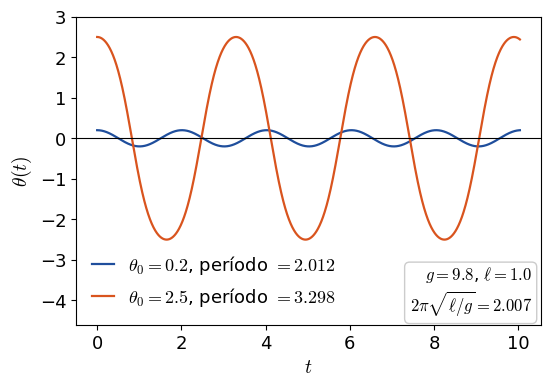

In [5]:
def pendulo(t, X, g, l):
    theta, omega = X
    return [omega, -g / l * np.sin(theta)]

g, l = 9.8, 1.0
T0 = 2 * np.pi * np.sqrt(l / g)
print(f"2 pi sqrt(l/g) = {T0:.4f}")

fig, ax = plt.subplots()
for theta0, c in zip([0.2, 2.5], CICLO):
    t, (theta, omega) = simular(pendulo, [theta0, 0.0], 5 * T0, args=(g, l))
    Tm = periodo(t, theta)
    ax.plot(t, theta, color=c, label=rf"$\theta_0 = {theta0}$, período $= {Tm:.3f}$")
    print(f"theta0 = {theta0}: período medido = {Tm:.4f}  (cociente con 2 pi sqrt(l/g): {Tm / T0:.4f})")
ax.axhline(0, color="black", lw=0.8)
ax.set_ylim(-4.6, 3.0); ax.set_xlabel("$t$"); ax.set_ylabel(r"$\theta(t)$"); ax.legend(loc="lower left", handlelength=1.2)
estilo.parametros(ax, rf"$g = {g}$, $\ell = {l}$" + "\n" + rf"$2\pi\sqrt{{\ell/g}} = {T0:.3f}$", loc="lower right", fontsize=12)
if GUARDAR: estilo.guardar(fig, "pendulo-simulacion")

In [6]:
# Período en función de la amplitud: la aproximación lineal es buena hasta unos 30 grados
for theta0 in [0.1, 0.5, 1.0, 1.5, 2.0, 2.5, 3.0]:
    t, (theta, _) = simular(pendulo, [theta0, 0.0], 12 * T0, args=(g, l), n=6000)
    print(f"theta0 = {theta0:.1f} rad ({np.degrees(theta0):5.1f} grados): T / T0 = {periodo(t, theta) / T0:.4f}")

theta0 = 0.1 rad (  5.7 grados): T / T0 = 1.0006


theta0 = 0.5 rad ( 28.6 grados): T / T0 = 1.0159


theta0 = 1.0 rad ( 57.3 grados): T / T0 = 1.0663


theta0 = 1.5 rad ( 85.9 grados): T / T0 = 1.1620


theta0 = 2.0 rad (114.6 grados): T / T0 = 1.3289


theta0 = 2.5 rad (143.2 grados): T / T0 = 1.6430


theta0 = 3.0 rad (171.9 grados): T / T0 = 2.5712


## 3.5 El péndulo amortiguado

$\ddot\theta + \alpha\dot\theta + \frac{g}{\ell}\sin\theta = 0$, con $\alpha>0$. La energía $E = \tfrac12\omega^2 + \frac{g}{\ell}(1-\cos\theta)$ verifica $\dot E = -\alpha\omega^2 \le 0$, igual que en el resorte con fricción: las oscilaciones se amortiguan y el péndulo termina colgando. (El retrato de fases completo de este sistema aparece más adelante en las notas.)

max |dE/dt + alpha omega^2| = 6.4e-03;  E(0) = 17.651, E(30) = 2.54e-03


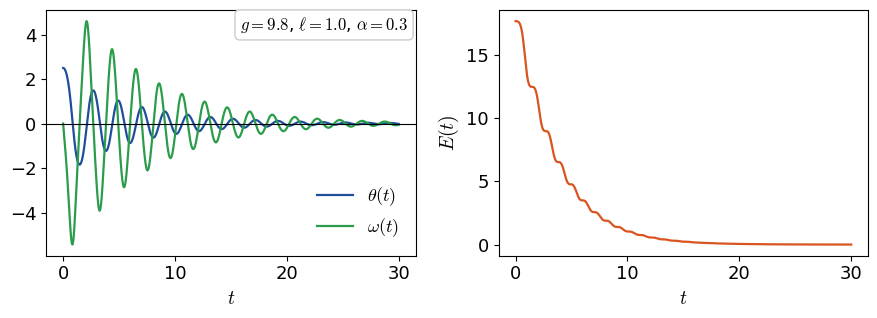

In [7]:
def pendulo_amortiguado(t, X, g, l, alpha):
    theta, omega = X
    return [omega, -alpha * omega - g / l * np.sin(theta)]

alpha = 0.3
E_pend = lambda theta, omega: 0.5 * omega**2 + g / l * (1 - np.cos(theta))
t, (theta, omega) = simular(pendulo_amortiguado, [2.5, 0.0], 30, args=(g, l, alpha))
E = E_pend(theta, omega)
print(f"max |dE/dt + alpha omega^2| = {np.max(np.abs(np.gradient(E, t) + alpha * omega**2)):.1e};  E(0) = {E[0]:.3f}, E(30) = {E[-1]:.2e}")

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(9, 3.4))
ax1.plot(t, theta, label=r"$\theta(t)$"); ax1.plot(t, omega, label=r"$\omega(t)$", color=CICLO[2])
ax1.axhline(0, color="black", lw=0.8); ax1.set_xlabel("$t$"); ax1.legend()
ax2.plot(t, E, color=CICLO[1]); ax2.set_xlabel("$t$"); ax2.set_ylabel("$E(t)$")
estilo.parametros(ax1, rf"$g = {g}$, $\ell = {l}$, $\alpha = {alpha}$", fontsize=12)
fig.tight_layout()

## 3.6 Circuitos eléctricos

Circuito RLC en serie: $L\dot x + Rx + v_C = v(t)$, $C\dot v_C = x$, donde $x$ es la corriente y $v_C$ el voltaje en el capacitor. Es el resorte con fricción con $m\leftrightarrow L$, $\gamma\leftrightarrow R$, $k\leftrightarrow 1/C$. Sin fuente y sin resistencia la corriente oscila con período $2\pi\sqrt{LC}$; con $R>0$ la oscilación se apaga. Lo verificamos simulando directamente el sistema $(x, v_C)$, sin pasar a la ecuación de segundo orden.

R = 0.0: período medido de la corriente = 6.2832;  2 pi sqrt(LC) = 6.2832;  |x| final = 0.373
R = 0.5: período medido de la corriente = 6.1158;  2 pi sqrt(LC) = 6.2832;  |x| final = 0.003


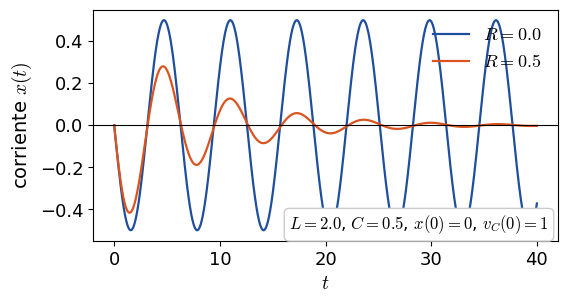

In [8]:
def RLC(t, X, L, R, C):
    x, vC = X
    return [(-R * x - vC) / L, x / C]

L, C = 2.0, 0.5
for R in [0.0, 0.5]:
    t, (x, vC) = simular(RLC, [0.0, 1.0], 40, args=(L, R, C))
    print(f"R = {R}: período medido de la corriente = {periodo(t, x):.4f};  2 pi sqrt(LC) = {2 * np.pi * np.sqrt(L * C):.4f};  |x| final = {abs(x[-1]):.3f}")

fig, ax = plt.subplots(figsize=(6, 3))
for R, c in zip([0.0, 0.5], CICLO):
    t, (x, vC) = simular(RLC, [0.0, 1.0], 40, args=(L, R, C))
    ax.plot(t, x, color=c, label=f"$R = {R}$")
ax.axhline(0, color="black", lw=0.8); ax.set_xlabel("$t$"); ax.set_ylabel("corriente $x(t)$"); ax.legend(loc="upper right")
estilo.parametros(ax, rf"$L = {L}$, $C = {C}$, $x(0)=0$, $v_C(0)=1$", loc="lower right", fontsize=12)

### Volvemos al circuito: la ecuación de van der Pol

Con el elemento resistivo no lineal $v_R(x) = -ax + bx^3$ y adimensionalizando (Sección 1.2 de las notas), la corriente verifica
$$\ddot x + \lambda(x^2-1)\dot x + x = 0,\qquad \lambda = a\sqrt{C/L} > 0,$$
o como sistema, $\dot x = y$, $\dot y = -x - \lambda(x^2-1)y$. El tiempo está medido en unidades de $\sqrt{LC}$, así que el período natural del circuito es $2\pi$.

Las dos primeras preguntas del problema conductor eran: si perturbamos apenas el reposo, ¿el circuito se enciende?, y si se enciende, ¿la corriente se estabiliza en una oscilación de amplitud definida? Simulamos desde una corriente inicial muy chica para dos valores de $\lambda$.

*Figura nueva `circuito-vdp-corriente`: corriente $x(t)$ del circuito de van der Pol para $\lambda$ chico (oscilación casi sinusoidal) y $\lambda$ grande (oscilación de relajación).*

lambda = 0.1: período medido = 6.286 (natural: 2 pi = 6.283), amplitud en régimen permanente = 1.994


lambda = 5.0: período medido = 11.612 (natural: 2 pi = 6.283), amplitud en régimen permanente = 2.022


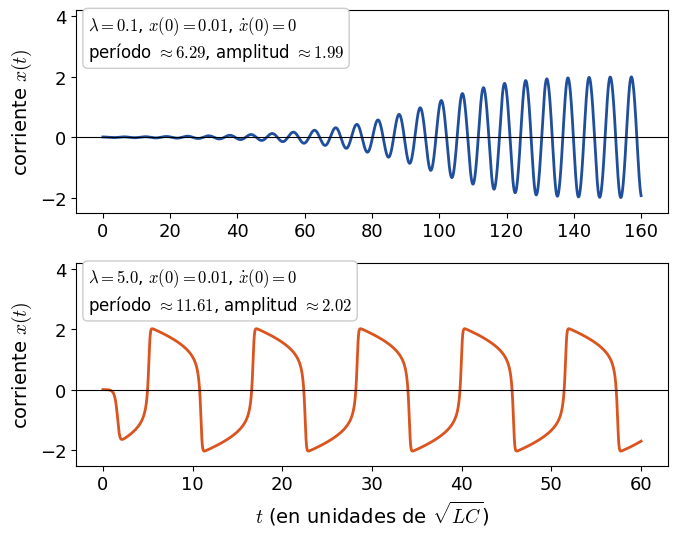

In [9]:
def vdP(t, X, lam):
    x, y = X
    return [y, -x - lam * (x**2 - 1) * y]

casos = [(0.1, 160), (5.0, 60)]          # (lambda, tiempo de simulación)
fuente(14, lw=2)
fig, axs = plt.subplots(2, 1, figsize=(7, 5.6), sharey=True)
axs[0].set_ylim(-2.5, 4.2)
for ax, (lam, T), c in zip(axs, casos, CICLO):
    t, (x, y) = simular(vdP, [0.01, 0.0], T, args=(lam,), n=6000)
    ax.plot(t, x, color=c)
    ax.axhline(0, color="black", lw=0.8)
    Tm = periodo(t, x, descartar=0.6 * T)
    amp = np.max(np.abs(x[t > 0.6 * T]))
    ax.set_ylabel("corriente $x(t)$")
    estilo.parametros(ax, rf"$\lambda = {lam}$, $x(0) = 0.01$, $\dot x(0) = 0$" + "\n" + rf"período $\approx {Tm:.2f}$, amplitud $\approx {amp:.2f}$", loc="upper left", fontsize=12)
    print(f"lambda = {lam}: período medido = {Tm:.3f} (natural: 2 pi = {2 * np.pi:.3f}), amplitud en régimen permanente = {amp:.3f}")
axs[-1].set_xlabel("$t$ (en unidades de $\sqrt{LC}$)")
fig.tight_layout(); fuente()
if GUARDAR: estilo.guardar(fig, "circuito-vdp-corriente")

In [10]:
# La amplitud y el período NO dependen del estado inicial: distintas condiciones iniciales terminan en la misma oscilación
lam = 1.0
for X0 in [(0.01, 0.0), (0.5, 0.5), (3.0, 0.0), (0.0, -4.0)]:
    t, (x, y) = simular(vdP, X0, 80, args=(lam,), n=6000)
    print(f"X0 = {X0}: período = {periodo(t, x, descartar=50):.4f}, amplitud = {np.max(np.abs(x[t > 50])):.4f}")

X0 = (0.01, 0.0): período = 6.6633, amplitud = 2.0086


X0 = (0.5, 0.5): período = 6.6633, amplitud = 2.0086


X0 = (3.0, 0.0): período = 6.6633, amplitud = 2.0086


X0 = (0.0, -4.0): período = 6.6633, amplitud = 2.0086


## 3.8 La energía como herramienta

Para van der Pol tomamos la energía del oscilador sin fricción, $E = \tfrac12(x^2+y^2)$, y a lo largo de las soluciones
$$\dot E = -\lambda(x^2-1)\,y^2 .$$
Con $\lambda>0$: mientras $|x|<1$ la energía crece (el elemento entrega energía: el circuito se enciende), y cuando $|x|>1$ decrece (las oscilaciones grandes se amortiguan). $E$ no es monótona: por eso el circuito no puede ni quedarse en reposo ni crecer sin límite, y termina en una oscilación de amplitud intermedia.

*Figura nueva `energia-vdp`: $E(t)$ a lo largo de una solución que arranca cerca del reposo, y el signo de $\dot E$ comparado con la franja $|x|<1$.*

max |dE/dt (numérico) - (-lambda (x^2-1) y^2)| = 2.3e-03
E(0) = 0.005; E crece hasta 4.004 y en régimen permanente oscila entre 1.173 y 4.004


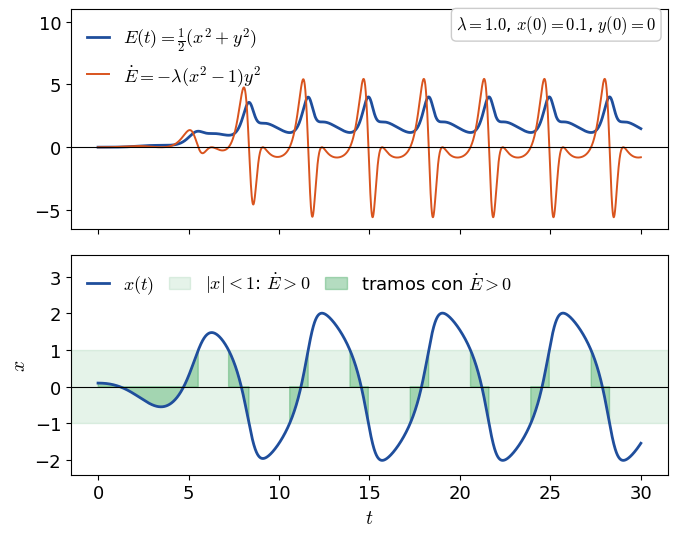

In [11]:
lam = 1.0
t, (x, y) = simular(vdP, [0.1, 0.0], 30, args=(lam,), n=4000)
E = 0.5 * (x**2 + y**2)
dE = -lam * (x**2 - 1) * y**2
print(f"max |dE/dt (numérico) - (-lambda (x^2-1) y^2)| = {np.max(np.abs(np.gradient(E, t) - dE)):.1e}")
print(f"E(0) = {E[0]:.3f}; E crece hasta {E.max():.3f} y en régimen permanente oscila entre {E[t > 20].min():.3f} y {E[t > 20].max():.3f}")

fuente(14, lw=2)
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(7, 5.6), sharex=True)
ax1.plot(t, E, color=COLORES["traj"], label=r"$E(t) = \frac{1}{2}(x^2+y^2)$")
ax1.plot(t, dE, color=COLORES["modelo"], lw=1.4, label=r"$\dot E = -\lambda(x^2-1)y^2$")
ax1.axhline(0, color="black", lw=0.8); ax1.set_ylim(-6.5, 11); ax1.legend(loc="upper left", ncol=1, handlelength=1.2)
ax2.plot(t, x, color=COLORES["traj"], label="$x(t)$")
ax2.axhspan(-1, 1, color=COLORES["nul_p"], alpha=0.12, label=r"$|x|<1$: $\dot E > 0$")
ax2.fill_between(t, x, 0, where=dE > 0, color=COLORES["nul_p"], alpha=0.35, label=r"tramos con $\dot E>0$")
ax2.axhline(0, color="black", lw=0.8); ax2.set_ylim(-2.4, 3.2); ax2.set_ylim(-2.4, 3.6); ax2.set_xlabel("$t$"); ax2.set_ylabel("$x$"); ax2.legend(loc="upper left", ncol=3, handlelength=1.2, columnspacing=0.8)
estilo.parametros(ax1, rf"$\lambda = {lam}$, $x(0) = 0.1$, $y(0) = 0$", loc="upper right", fontsize=12)
fig.tight_layout(); fuente()
if GUARDAR: estilo.guardar(fig, "energia-vdp")

In [12]:
# lambda < 0: el elemento disipa siempre que |x| < 1 y el reposo atrae a las soluciones que arrancan ahí
for lam in [-0.5, 0.5]:
    t, (x, y) = simular(vdP, [0.5, 0.0], 60, args=(lam,))
    E = 0.5 * (x**2 + y**2)
    print(f"lambda = {lam}: E(0) = {E[0]:.3f} -> E(60) = {E[-1]:.4f}   ({'vuelve al reposo' if E[-1] < 1e-2 else 'se enciende'})")


lambda = -0.5: E(0) = 0.125 -> E(60) = 0.0000   (vuelve al reposo)
lambda = 0.5: E(0) = 0.125 -> E(60) = 2.0062   (se enciende)


## Para experimentar

1. En el oscilador armónico, cambiá $m$ y $k$ y verificá que el período medido sigue siendo $2\pi\sqrt{m/k}$ y no depende de $x_0$.
2. En `resorte`, buscá el valor de $\gamma$ a partir del cual $x(t)$ deja de cruzar el cero, y comparalo con $2\sqrt{km}$.
3. Arrancá el péndulo con $\theta_0 = 0$ y una velocidad $\omega_0$ grande. ¿Qué pasa con $\theta(t)$? ¿Para qué $\omega_0$ cambia el comportamiento? Pensalo con la energía $\tfrac12\omega^2 + \frac{g}{\ell}(1-\cos\theta)$.
4. Medí el período de la oscilación de van der Pol para $\lambda = 0.1, 0.5, 1, 2, 5, 10$ y graficalo contra $\lambda$. ¿Para qué valores se parece al período natural $2\pi$?